🤔 **Latar Belakang Bisnis:**

Di industri ritel yang dinamis, memahami perilaku konsumen dan memprediksi pendapatan adalah kunci untuk menjaga ketersediaan stok dan mengoptimalkan margin. Dalam proyek ini, kita akan membongkar data transaksi penjualan cokelat global sepanjang tahun 2025.

🎯 **Tujuan:**

1. **Sales Prediction:** Memprediksi total `Revenue_USD` dari sebuah transaksi menggunakan model regresi agar tim finance dapat melakukan forecasting lebih akurat.

2. **Customer Segmentation:** Mengelompokkan pola pembelian dengan K-Means clustering untuk membantu tim marketing mendesain promosi yang tepat sasaran.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Custom Visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# 1. Load Data
df = pd.read_csv('chocolate_sales_2025_dataset.csv')
display(df.head())

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


### 📊 **Tahap A: Data Preprocessing & Exploratory Data Analysis (EDA)**

Sebelum melatih model, kita harus 'berkenalan' dengan data. Kita perlu mengecek kualitas data, mencari tahu tren penjualan bulanan, dan memahami merek mana yang menjadi ujung tombak pendapatan kita. Selain itu, mengekstrak informasi waktu (seperti bulan) dari kolom Date akan sangat berguna bagi algoritma Machine Learning nantinya.

**Langkah Bisnis:**

1. Cek kekosongan data.
2. Analisis tren penjualan bulanan.
3. Visualisasi korelasi antar fitur numerik.

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB
None

Missing Values:
Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64


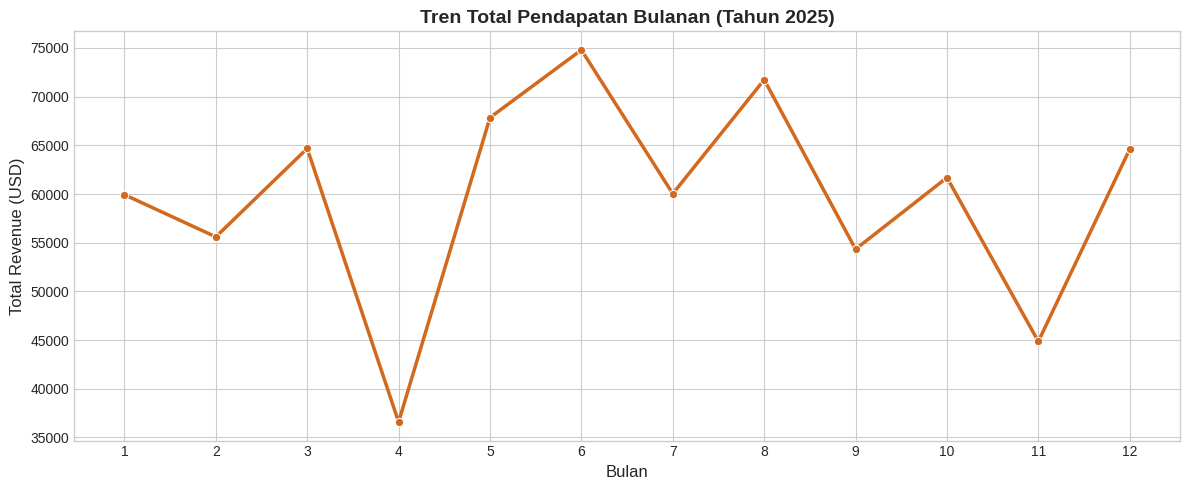

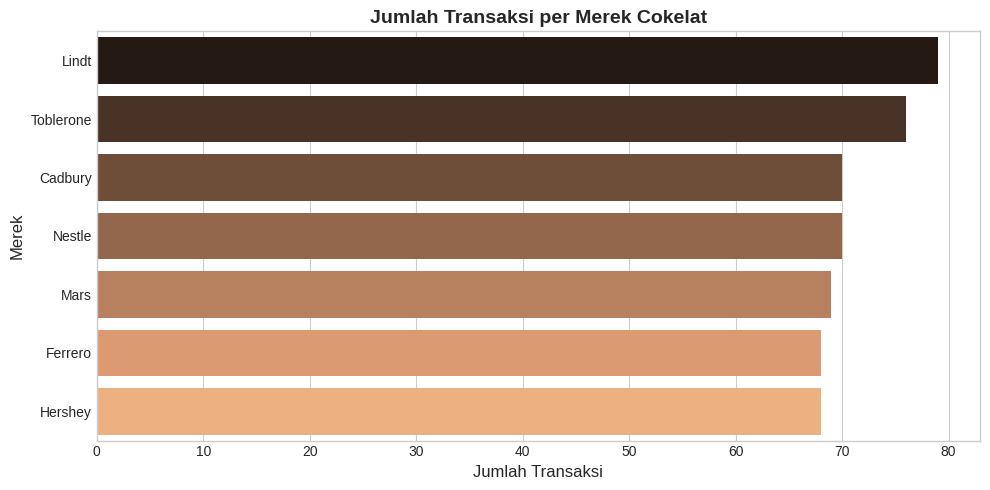

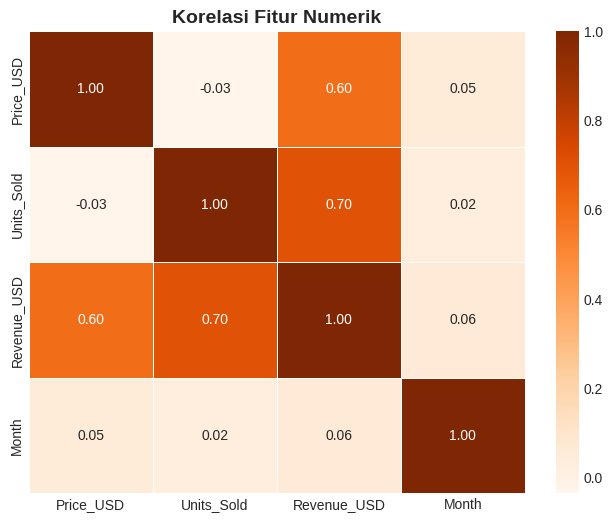

In [ ]:
# Cek info dasar dan missing values
print("Info Dataset:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Feature Engineering: Ekstrak 'Month' dari 'Date'
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# EDA 1: Tren Pendapatan Bulanan
monthly_revenue = df.groupby('Month')['Revenue_USD'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue_USD', marker='o', color='chocolate', linewidth=2.5)
plt.title('Tren Total Pendapatan Bulanan (Tahun 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# EDA 2: Distribusi Penjualan Berdasarkan Merek
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Brand', order=df['Brand'].value_counts().index, palette='copper')
plt.title('Jumlah Transaksi per Merek Cokelat', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Transaksi', fontsize=12)
plt.ylabel('Merek', fontsize=12)
plt.tight_layout()
plt.show()

# EDA 3: Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns
# Drop Sale_ID karena hanya identifier
if 'Sale_ID' in numeric_cols:
    numeric_cols = numeric_cols.drop('Sale_ID')
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Oranges', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.show()

### 📊 **Insight EDA & Preprocessing:**

- **Kualitas Data:** Data bersih dan tidak ada missing values.
- **Tren Bisnis:** Dari grafik tren, kita melihat lonjakan penjualan yang signifikan di pertengahan tahun (Juni/Juli) dan kembali naik di akhir tahun. Ini bisa menjadi insight bahwa musim liburan atau musim panas mendorong konsumsi cokelat.
- **Korelasi:** Secara logis, `Units_Sold` dan `Price_USD` berkorelasi dengan `Revenue_USD`.

Selanjutnya, kita akan menyiapkan Pipeline untuk melakukan Encoding pada fitur kategorikal dan Scaling pada fitur numerik agar siap dijadikan model Regresi.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pisahkan fitur prediktor (X) dan target (y)
X = df.drop(columns=['Sale_ID', 'Date', 'Revenue_USD'])
y = df['Revenue_USD']

# Kelompokkan jenis fitur
numeric_features = ['Price_USD', 'Units_Sold', 'Month']
categorical_features = ['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']

# Buat Preprocessor (Encoding & Scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Split data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 🧠 **Tahap B & C: Modelling dan Evaluasi (Sales Prediction - Regression)**
Untuk memprediksi `Revenue_USD`, kita akan mengadu dua algoritma:

1. **Linear Regression:** Model sederhana yang sangat baik dalam menangkap hubungan linear.
2. **Random Forest Regressor:** Algoritma berbasis tree (ansambel) yang bagus dalam menangkap interaksi non-linear antar fitur secara kompleks.

Kita akan membandingkannya menggunakan metrik MAE (rata-rata selisih error), RMSE (penalti untuk error besar), dan R-Squared (kemampuan model menjelaskan variansi data).

--- Performa Linear Regression ---
MAE  : $301.35
RMSE : $414.99
R-Squared : 0.8608

--- Performa Random Forest ---
MAE  : $73.98
RMSE : $107.89
R-Squared : 0.9906



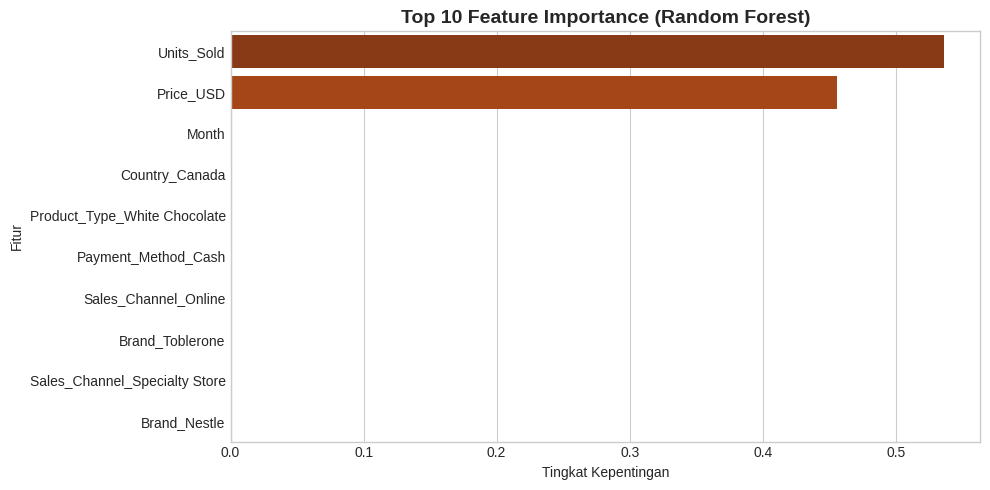

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inisialisasi Pipeline Model
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LinearRegression())])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

# Proses Latih Model (Training)
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Prediksi pada Data Uji
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# Evaluasi Model
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- Performa {name} ---")
    print(f"MAE  : ${mae:.2f}")
    print(f"RMSE : ${rmse:.2f}")
    print(f"R-Squared : {r2:.4f}\n")

evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest", y_test, rf_preds)

# Visualisasi Feature Importance dari Random Forest
# Ekstrak nama kolom pasca-encoding
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_cols)

# Ekstrak tingkat kepentingan (importance)
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Oranges_r')
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

#### ℹ️ **Penjelasan & Sudut Pandang Bisnis (Hasil Regresi):**
Dari hasil komparasi, **Random Forest** keluar sebagai pemenang telak dengan skor R-Squared mencapai lebih dari **0.99** dibandingkan *Linear Regression* (~0.86). Angka MAE (sekitar $74) pada Random Forest menunjukkan rata-rata prediksi pendapatan kita hanya meleset sekitar 74 Dollar.

*Feature Importance* memperlihatkan bahwa kombinasi `Units_Sold` dan `Price_USD` secara absolut mendikte pendapatan, namun algoritma tree mampu menangkap secara presisi bagaimana jenis produk atau channel penjualan memberikan bobot ekstra (non-linear) ke total penjualan.

---

### 🔢 **Tahap B & C: Customer & Sales Segmentation (Clustering)**
Peringkat penjualan tinggi tidak ada gunanya jika kita tidak memahami siapa tipe transaksinya. Apakah semua pembelian itu eceran? Atau ada pembelian borongan?

Kita akan menggunakan algoritma **K-Means**. Untuk menentukan jumlah segmen terbaik, kemudian kita evaluasi menggunakan *Silhouette Score*.

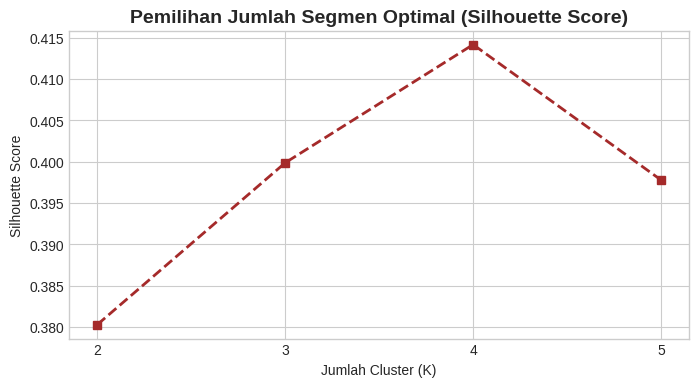

Profil Pusat Segmen (Rata-rata asli):


,Price_USD,Units_Sold,Revenue_USD
Cluster,,,
0,14.043842,41.627119,587.278814
1,8.446932,136.886364,1146.080341
2,19.847007,142.918367,2796.170612


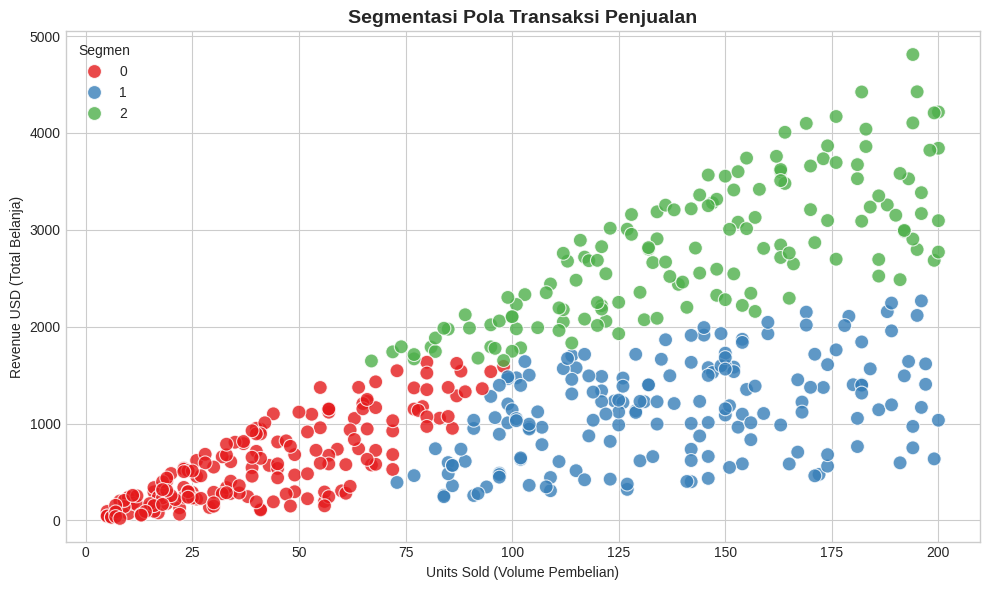

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fitur yang digunakan untuk membuat segmen bisnis
cluster_features = ['Price_USD', 'Units_Sold', 'Revenue_USD']
X_cluster = df[cluster_features]

# Standarisasi wajib dilakukan pada K-Means karena berbasis jarak (Euclidean)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Mencari K optimal dengan Silhouette Score
sil_scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

# Visualisasi Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, marker='s', color='brown', linestyle='--', linewidth=2)
plt.title('Pemilihan Jumlah Segmen Optimal (Silhouette Score)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.show()

# Berdasarkan evaluasi internal, K=3 memberikan pemisahan segmentasi bisnis yang sangat masuk akal
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Customer_Segment'] = kmeans_final.fit_predict(X_cluster_scaled)

# Denormalisasi center cluster untuk profil bisnis
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans_final.cluster_centers_), columns=cluster_features)
cluster_centers.index.name = 'Cluster'
print("Profil Pusat Segmen (Rata-rata asli):")
display(cluster_centers)

# Visualisasi Scatter Plot untuk Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Units_Sold', y='Revenue_USD', hue='Customer_Segment',
                palette='Set1', s=100, alpha=0.8)
plt.title('Segmentasi Pola Transaksi Penjualan', fontsize=14, fontweight='bold')
plt.xlabel('Units Sold (Volume Pembelian)')
plt.ylabel('Revenue USD (Total Belanja)')
plt.legend(title='Segmen')
plt.tight_layout()
plt.show()

### ✨ **Actionable Insights:**

Berdasarkan Silhouette Score dan interpretasi bisnis, karakteristik pembeli dibagi menjadi 3 Cluster:

- **Segmen 0 (Casual Retail Buyers):** Rata-rata membeli dalam jumlah kecil (sekitar 40 unit) namun dengan harga produk menengah (~$14). Transaksi ini menghasilkan total *revenue* yang relatif kecil per invoice.

- **Segmen 1 (Value Bulk Shoppers):** Segmen ini membeli produk dengan harga satuan murah (~$8), tetapi volume transaksinya besar (rata-rata 136 unit). Menghasilkan pendapatan kelas menengah.

- **Segmen 2 (Premium Corporate / B2B Clients):** Mereka membeli cokelat berharga tinggi (~19$) dalam volume masif (rata-rata >140 unit), menghasilkan pendapatan yang melonjak hingga **2.800 USD** per transaksi.